# Scenario Analysis

This notebook evaluates alternative pricing and cost scenarios using the 12-month baseline business forecast.

### Objectives
- Compare a baseline outlook with alternative fare scenarios
- Estimate the impact of fare changes on ridership and revenue
- Evaluate how cost pressure affects farebox recovery
- identify scenarios that best balance financial sustainability and demand

In [41]:
# Import libraries for data handling and plotting.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [42]:
# Set the project root path and load the baseline 12-month business forecast.
project_root = Path.cwd().parent
baseline_df = pd.read_csv(project_root / "data" / "processed" / "business_forecast_12m.csv")

# Convert the date column to datetime.
baseline_df["date"] = pd.to_datetime(baseline_df["date"])

baseline_df.head()

,year_month,date,forecast_boardings,projected_avg_fare,forecast_revenue,forecast_total_cost,forecast_farebox_recovery,lower_ci,upper_ci
0,2027-01,2027-01-01,8285.0,4.15,34400.98,39390.87,0.873,7716.0,8853.0
1,2027-02,2027-02-01,8814.0,4.16,36652.05,39366.90,0.931,8204.0,9424.0
2,2027-03,2027-03-01,8972.0,4.16,37364.63,39342.94,0.950,8284.0,9660.0
3,2027-04,2027-04-01,8925.0,4.17,37226.21,39319.00,0.947,8177.0,9673.0
4,2027-05,2027-05-01,8545.0,4.18,35695.97,39295.07,0.908,7739.0,9351.0


In [43]:
# Define scenario assumptions.
# fare_change_pct = percentage increase in fare
# elasticity = estimated ridership response to fare change
# cost_growth_adjustment = additional multiplier on forecasted total cost

scenarios = [
    {
        "scenario_name": "Base Case",
        "fare_change_pct": 0.00,
        "elasticity": 0.00,
        "cost_growth_adjustment": 0.00,
    },
    {
        "scenario_name": "Moderate Fare Increase",
        "fare_change_pct": 0.05,
        "elasticity": -0.20,
        "cost_growth_adjustment": 0.00,
    },
    {
        "scenario_name": "Higher Fare Increase",
        "fare_change_pct": 0.10,
        "elasticity": -0.30,
        "cost_growth_adjustment": 0.00,
    },
    {
        "scenario_name": "Fare Increase + Cost Pressure",
        "fare_change_pct": 0.05,
        "elasticity": -0.20,
        "cost_growth_adjustment": 0.08,
    },
]

In [44]:
# Apply each scenario to the baseline forecast and store the results.
scenario_outputs = []

for scenario in scenarios:
    temp_df = baseline_df.copy()

    # Adjust average fare.
    temp_df["scenario_avg_fare"] = temp_df["projected_avg_fare"] * (1 + scenario["fare_change_pct"])

    # Adjust ridership using a simple elasticity assumption.
    # Ridership change = fare change % * elasticity
    ridership_multiplier = 1 + (scenario["fare_change_pct"] * scenario["elasticity"])
    temp_df["scenario_boardings"] = temp_df["forecast_boardings"] * ridership_multiplier

    # Recalculate revenue under the scenario.
    temp_df["scenario_revenue"] = temp_df["scenario_boardings"] * temp_df["scenario_avg_fare"]

    # Adjust total cost if the scenario includes extra cost pressure.
    temp_df["scenario_total_cost"] = temp_df["forecast_total_cost"] * (1 + scenario["cost_growth_adjustment"])

    # Recalculate farebox recovery.
    temp_df["scenario_farebox_recovery"] = (
        temp_df["scenario_revenue"] / temp_df["scenario_total_cost"]
    )

    # Add scenario label.
    temp_df["scenario_name"] = scenario["scenario_name"]

    scenario_outputs.append(temp_df)

# Combine all scenarios into one table.
scenario_df = pd.concat(scenario_outputs, ignore_index=True)

scenario_df.head()

,year_month,date,forecast_boardings,projected_avg_fare,forecast_revenue,forecast_total_cost,forecast_farebox_recovery,lower_ci,upper_ci,scenario_avg_fare,scenario_boardings,scenario_revenue,scenario_total_cost,scenario_farebox_recovery,scenario_name
0,2027-01,2027-01-01,8285.0,4.15,34400.98,39390.87,0.873,7716.0,8853.0,4.15,8285.0,34382.75,39390.87,0.872861,Base Case
1,2027-02,2027-02-01,8814.0,4.16,36652.05,39366.90,0.931,8204.0,9424.0,4.16,8814.0,36666.24,39366.90,0.931398,Base Case
2,2027-03,2027-03-01,8972.0,4.16,37364.63,39342.94,0.950,8284.0,9660.0,4.16,8972.0,37323.52,39342.94,0.948671,Base Case
3,2027-04,2027-04-01,8925.0,4.17,37226.21,39319.00,0.947,8177.0,9673.0,4.17,8925.0,37217.25,39319.00,0.946546,Base Case
4,2027-05,2027-05-01,8545.0,4.18,35695.97,39295.07,0.908,7739.0,9351.0,4.18,8545.0,35718.10,39295.07,0.908972,Base Case


In [45]:
# Round scenario fields for cleaner display.
scenario_df["scenario_avg_fare"] = scenario_df["scenario_avg_fare"].round(2)
scenario_df["scenario_boardings"] = scenario_df["scenario_boardings"].round(0)
scenario_df["scenario_revenue"] = scenario_df["scenario_revenue"].round(2)
scenario_df["scenario_total_cost"] = scenario_df["scenario_total_cost"].round(2)
scenario_df["scenario_farebox_recovery"] = scenario_df["scenario_farebox_recovery"].round(3)

scenario_df.head()

,year_month,date,forecast_boardings,projected_avg_fare,forecast_revenue,forecast_total_cost,forecast_farebox_recovery,lower_ci,upper_ci,scenario_avg_fare,scenario_boardings,scenario_revenue,scenario_total_cost,scenario_farebox_recovery,scenario_name
0,2027-01,2027-01-01,8285.0,4.15,34400.98,39390.87,0.873,7716.0,8853.0,4.15,8285.0,34382.75,39390.87,0.873,Base Case
1,2027-02,2027-02-01,8814.0,4.16,36652.05,39366.90,0.931,8204.0,9424.0,4.16,8814.0,36666.24,39366.90,0.931,Base Case
2,2027-03,2027-03-01,8972.0,4.16,37364.63,39342.94,0.950,8284.0,9660.0,4.16,8972.0,37323.52,39342.94,0.949,Base Case
3,2027-04,2027-04-01,8925.0,4.17,37226.21,39319.00,0.947,8177.0,9673.0,4.17,8925.0,37217.25,39319.00,0.947,Base Case
4,2027-05,2027-05-01,8545.0,4.18,35695.97,39295.07,0.908,7739.0,9351.0,4.18,8545.0,35718.10,39295.07,0.909,Base Case


In [46]:
# Summarize each scenario across the 12-month forecast horizon.
scenario_summary = (
    scenario_df.groupby("scenario_name")[
        ["scenario_boardings", "scenario_revenue", "scenario_total_cost", "scenario_farebox_recovery"]
    ]
    .mean()
    .round(2)
    .sort_values("scenario_farebox_recovery", ascending=False)
)

scenario_summary

,scenario_boardings,scenario_revenue,scenario_total_cost,scenario_farebox_recovery
scenario_name,,,,
Higher Fare Increase,7953.42,36612.18,39259.30,0.93
Moderate Fare Increase,8117.42,35668.56,39259.30,0.91
Base Case,8199.42,34313.19,39259.30,0.87
Fare Increase + Cost Pressure,8117.42,35668.56,42400.04,0.84


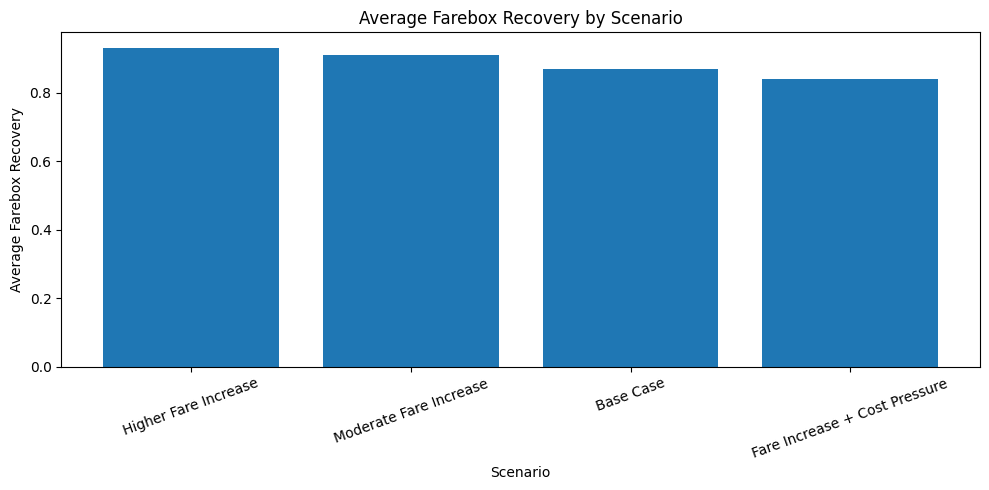

In [47]:
# Plot average farebox recovery for each scenario.
plt.figure(figsize=(10, 5))
plt.bar(scenario_summary.index, scenario_summary["scenario_farebox_recovery"])
plt.title("Average Farebox Recovery by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Average Farebox Recovery")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

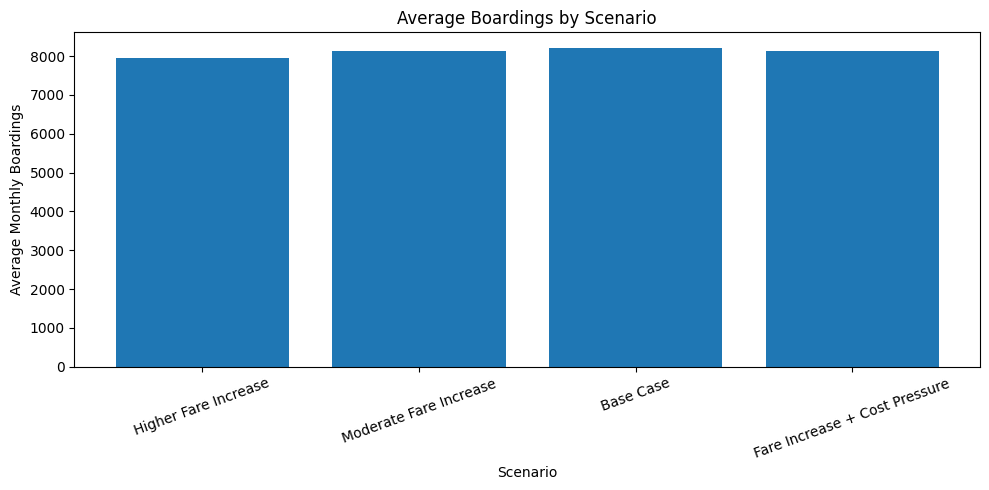

In [48]:
# Plot average boardings for each scenario.
plt.figure(figsize=(10, 5))
plt.bar(scenario_summary.index, scenario_summary["scenario_boardings"])
plt.title("Average Boardings by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Average Monthly Boardings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

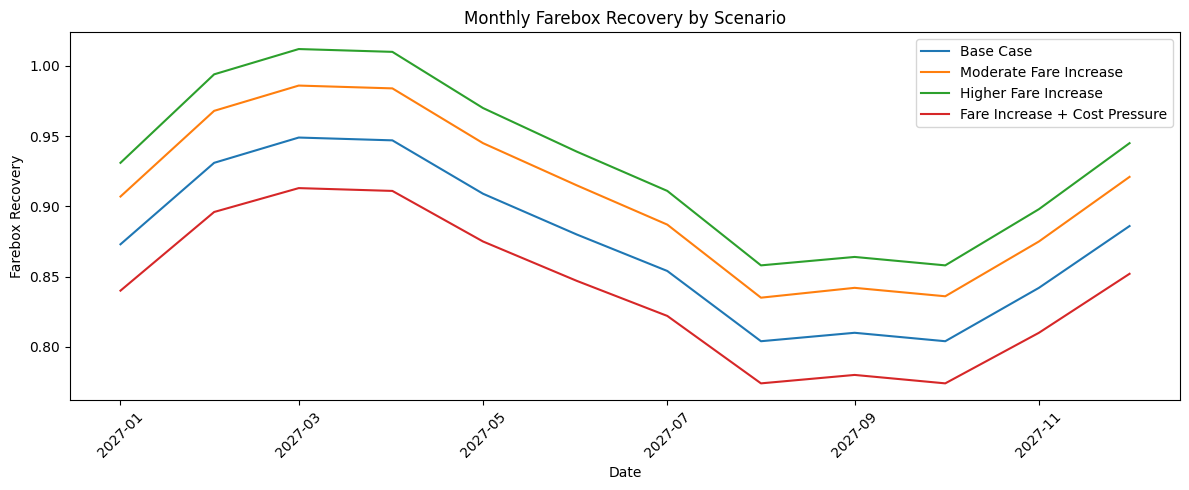

In [49]:
# Plot monthly farebox recovery paths for all scenarios.
plt.figure(figsize=(12, 5))

for scenario_name in scenario_df["scenario_name"].unique():
    temp = scenario_df[scenario_df["scenario_name"] == scenario_name]
    plt.plot(temp["date"], temp["scenario_farebox_recovery"], label=scenario_name)

plt.title("Monthly Farebox Recovery by Scenario")
plt.xlabel("Date")
plt.ylabel("Farebox Recovery")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# Save detailed scenario outputs and scenario summary.
scenario_output_file = project_root / "data" / "processed" / "scenario_analysis_output.csv"
scenario_summary_file = project_root / "data" / "processed" / "scenario_summary.csv"

scenario_df.to_csv(scenario_output_file, index=False)
scenario_summary.to_csv(scenario_summary_file)

print(f"Scenario output saved to: {scenario_output_file}")
print(f"Scenario summary saved to: {scenario_summary_file}")

Scenario output saved to: /Users/ashwinphilip/Transit-Rideshare-Analysis/data/processed/scenario_analysis_output.csv
Scenario summary saved to: /Users/ashwinphilip/Transit-Rideshare-Analysis/data/processed/scenario_summary.csv


### Scenario Takeaways

- Under the current assumptions, fare increases improve average farebox recovery despite a modest reduction in ridership.
- The higher fare increase scenario produces the strongest financial outcome, but it also results in the largest boarding decline.
- The cost pressure scenario shows that rising operating costs can materially reduce the benefit of fare changes.
- A moderate fare increase may provide a more balanced tradeoff between financial improvement and ridership preservation.
- Final decisions should consider service goals, rider sensitivity, and broader agency priorities in addition to cost recovery.